# Plotting Eigenvalues

In [ ]:
from ast import literal_eval

import einops
import matplotlib.pyplot as plt
import matrepr
import numpy as np
import numpy.random as rnd
import pykoopman as pk
import torch
from matrepr import mprint
from pydmd import DMD, FbDMD
from safetensors.torch import load_file, load_model, save_model
from torch.nn import functional as F
from torch.utils.data import DataLoader, Subset
from torcheval.metrics import MulticlassAccuracy
from torchvision import datasets, transforms

from learningdynamics.dmd_data import reshape_append_time
from learningdynamics.models import MLP, init_weights
from learningdynamics.utils import (
    compute_model_accuracy,
    getActivation,
    safetensors_metadata_parser,
)
import string

In [ ]:
# | hide
np.random.seed(42)  # for reproducibility
%matplotlib inline

In [ ]:
LAYER_START = 1

In [ ]:
# Load model
file_path = f"../saved_weights/mnist_start{LAYER_START}_states.safetensors"

metadata = safetensors_metadata_parser(file_path=file_path)
NUM_TRAJECTORIES = literal_eval(metadata["num_trajectories"])
NUM_STATES = literal_eval(metadata["num_states"])
NUM_ITERATIONS = literal_eval(metadata["num_iterations"])

data = load_file(file_path)

In [ ]:
t = np.arange(0, NUM_ITERATIONS, 1)

In [ ]:
# Example values for NUM_TRAJECTORIES and NUM_DELAYS
NUM_TRAJECTORIES_LIST = [50, 500]
NUM_DELAYS_LIST = [1, 10, 50, 100]

# Dictionary to store the eigenvalues for each combination of trajectories and delays
eigenvalues_dict = {}

for num_trajectories in NUM_TRAJECTORIES_LIST:
    print(f"Trajectories {num_trajectories}..")
    for num_delays in NUM_DELAYS_LIST:
        print(f"Delays {num_delays}..")
        train_states = reshape_append_time(
            data["train_states"][:NUM_ITERATIONS, :num_trajectories, :NUM_STATES]
        )
        observables = pk.observables.TimeDelay(delay=1, n_delays=num_delays)

        regressor = pk.regression.EDMD(svd_rank=350)
        dmd_model = pk.Koopman(observables=observables, regressor=regressor)
        _ = dmd_model.fit(train_states.numpy().T)

        koop_eigenvals = np.diag(dmd_model.lamda)
        filtered_eigenvals = koop_eigenvals[np.abs(koop_eigenvals) > 0.7]

        eigenvalues_dict[(num_trajectories, num_delays)] = filtered_eigenvals


Trajectories 50..
Delays 1..
Delays 10..
Delays 50..
Delays 100..
Trajectories 500..
Delays 1..
Delays 10..
Delays 50..
Delays 100..


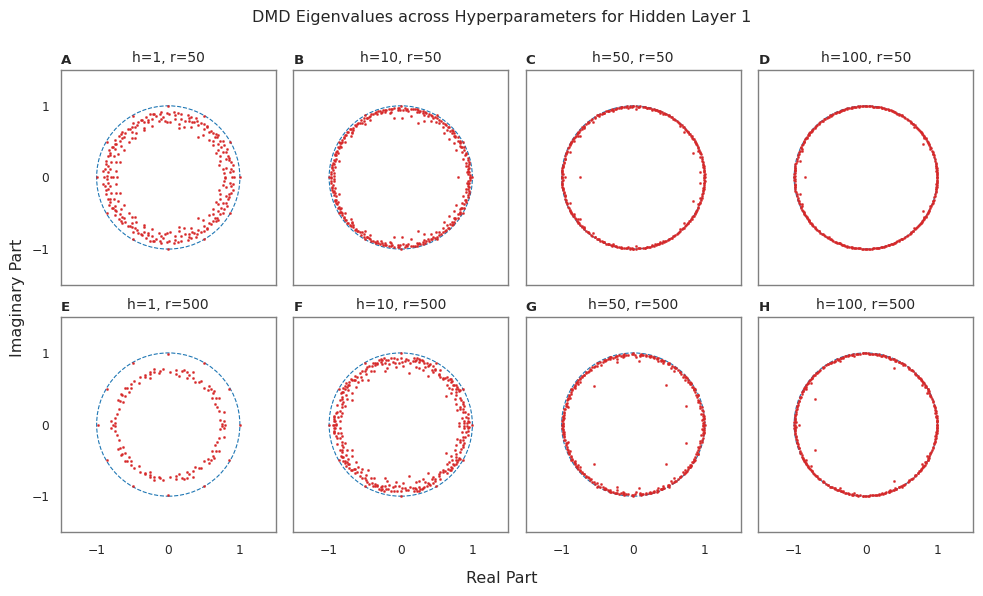

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn context and style
sns.set_context("paper")
sns.set_style("white")

keys = list(string.ascii_uppercase[:8])

# Create a figure and an array of subplots
fig, axes = plt.subplots(len(NUM_TRAJECTORIES_LIST), len(NUM_DELAYS_LIST), figsize=(3*len(NUM_DELAYS_LIST), 3*len(NUM_TRAJECTORIES_LIST)), sharex=True, sharey=True)
plt.rcParams['text.usetex'] = False

for i, num_trajectories in enumerate(NUM_TRAJECTORIES_LIST):
    for j, num_delays in enumerate(NUM_DELAYS_LIST):
        filtered_eigenvals = eigenvalues_dict[(num_trajectories, num_delays)]
        
        ax = axes[i, j]

        # Plot the unit circle
        unit_circle = plt.Circle((0, 0), 1, color="tab:blue", fill=False, linestyle="--")
        ax.add_artist(unit_circle)

        # Plot the eigenvalues
        sns.scatterplot(x=filtered_eigenvals.real, y=filtered_eigenvals.imag, color="tab:red", edgecolor=None, s=10, marker=".", ax=ax)

        # Set the axis limits
        ax.set_xlim([-1.5, 1.5])
        ax.set_ylim([-1.5, 1.5])

        # Set the ticks on both axes
        ax.set_xticks([-1, 0, 1])
        ax.set_yticks([-1, 0, 1])

        # Add grid, legend, and labels
        ax.set_aspect("equal", adjustable="box")
        ax.set_title(f"h={num_delays}, r={num_trajectories}", fontsize=10)

        # Make the edges of the plot box light gray
        for spine in ax.spines.values():
            spine.set_color('gray')
        ax.text(0.00, 1.03, keys[j+(len(NUM_DELAYS_LIST)*i)], transform=ax.transAxes, weight='bold')

# Add global x and y labels
fig.supxlabel("Real Part", y=0.02)
fig.supylabel("Imaginary Part", x=0.09)
fig.suptitle(f"DMD Eigenvalues across Hyperparameters for Hidden Layer {(LAYER_START+1)//2}")

plt.subplots_adjust(wspace=0, hspace=0.15)  # Modify these values to control spacing
plt.savefig(f'mnist_eigenvalues_start{LAYER_START}.pdf', format='pdf', bbox_inches='tight', pad_inches=0)
plt.show()